In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

from koala.pointsets import uniform, move_all_points, move_point, grid

400
400


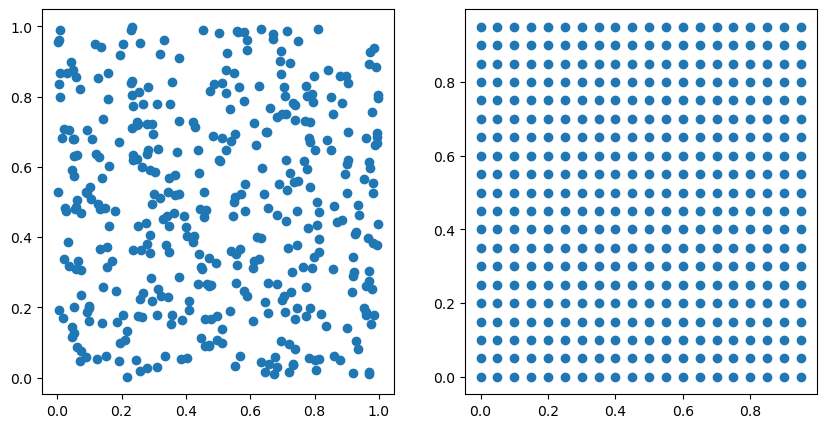

In [4]:
# make grid
L = 20

p_random = uniform(L**2)
p_regular = grid(L, L)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(*p_random.T)
ax[1].scatter(*p_regular.T)

print(len(p_random))
print(len(p_regular))

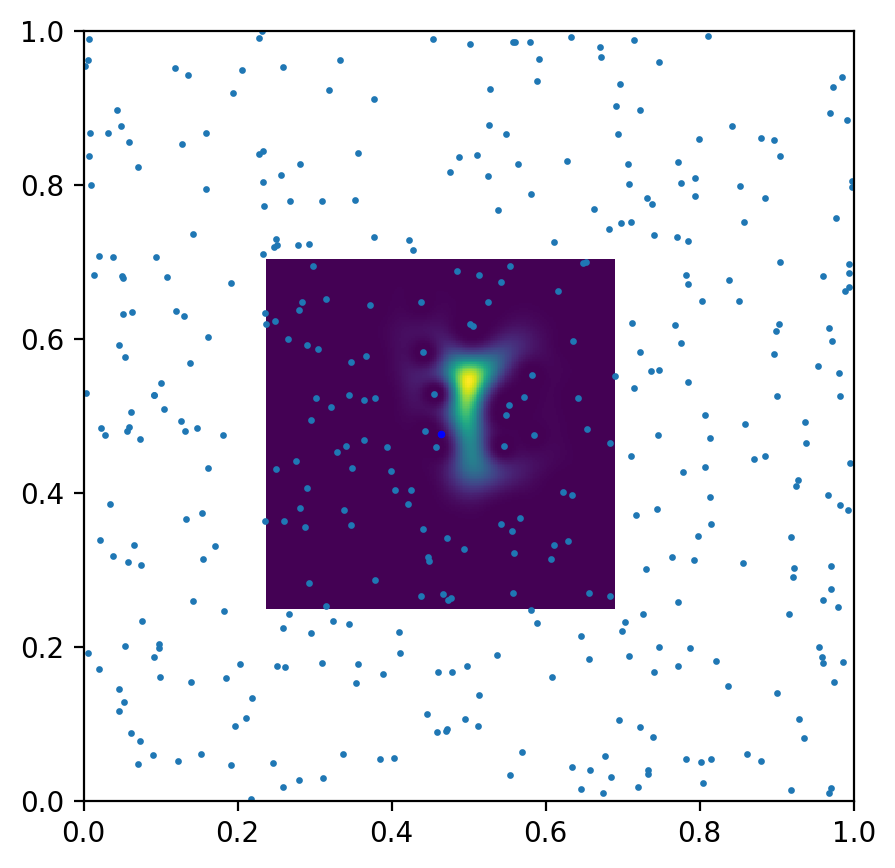

In [5]:
sigma = 2 / (L * np.sqrt(np.pi))  # how far is each point allowed to move
kappa = sigma  # lengthscale of how close you can get to each other vertex
beta = 1  # large beta forbids the system from choosing unlikely points
resolution = 200  # how finely sampled is the area to move to


# choose the point to move
d_from_center = p_random - 0.5
central_point = np.argmin(np.sum((p_random - 0.5) ** 2, axis=1))
_ = move_point(
    p_random,
    central_point,
    sigma,
    kappa,
    beta=beta,
    resolution=resolution,
    debug_plot=True,
)

100%|██████████| 10/10 [00:07<00:00,  1.26it/s]


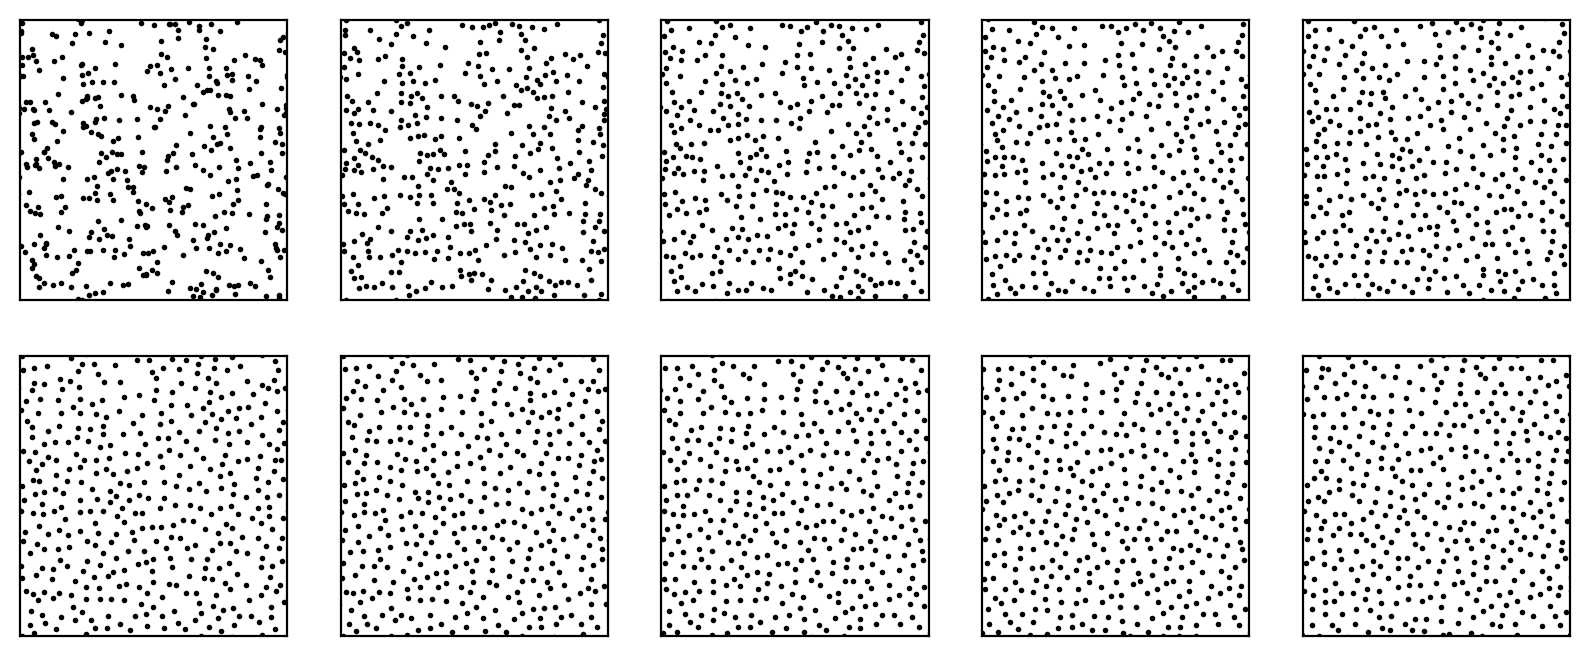

In [6]:
n_steps = 10


sigma = 1 / (2 * L * np.sqrt(np.pi))  # how far is each point allowed to move
kappa = 2 * sigma  # lengthscale of how close you can get to each other vertex
beta = 7  # large beta forbids the system from choosing unlikely points
resolution = 20  # how finely sampled is the area to move to

p_new = p_random.copy()
fig, ax = plt.subplots(n_steps // 5, 5, figsize=(10, 2 * n_steps // 5), dpi=200)
ax = ax.flatten()
for a in tqdm(ax):
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    s = 1
    a.scatter(*p_new.T, s=s, c="k")
    a.scatter(*(p_new + (0, 1)).T, s=s, c="k")
    a.scatter(*(p_new + (1, 0)).T, s=s, c="k")
    a.scatter(*(p_new + (0, -1)).T, s=s, c="k")
    a.scatter(*(p_new + (-1, 0)).T, s=s, c="k")

    p_new = move_all_points(p_new, sigma, kappa, beta, resolution=30)

plt.show()

100%|██████████| 10/10 [00:07<00:00,  1.28it/s]


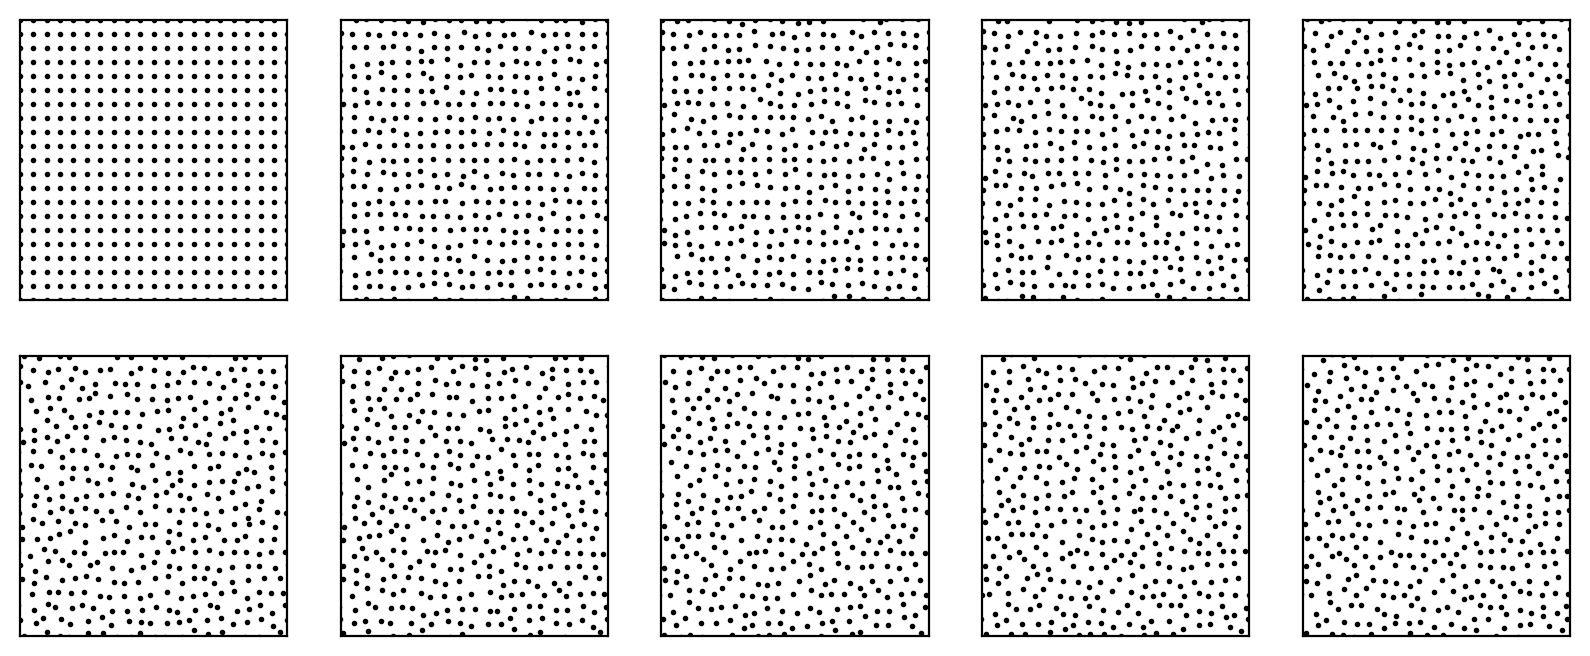

In [7]:
p_new = p_regular.copy()
fig, ax = plt.subplots(n_steps // 5, 5, figsize=(10, 2 * n_steps // 5), dpi=200)
ax = ax.flatten()
for a in tqdm(ax):
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    s = 1
    a.scatter(*p_new.T, s=s, c="k")
    a.scatter(*(p_new + (0, 1)).T, s=s, c="k")
    a.scatter(*(p_new + (1, 0)).T, s=s, c="k")
    a.scatter(*(p_new + (0, -1)).T, s=s, c="k")
    a.scatter(*(p_new + (-1, 0)).T, s=s, c="k")

    p_new = move_all_points(p_new, sigma, kappa, beta, resolution=30)

plt.show()

100%|██████████| 10/10 [00:06<00:00,  1.66it/s]


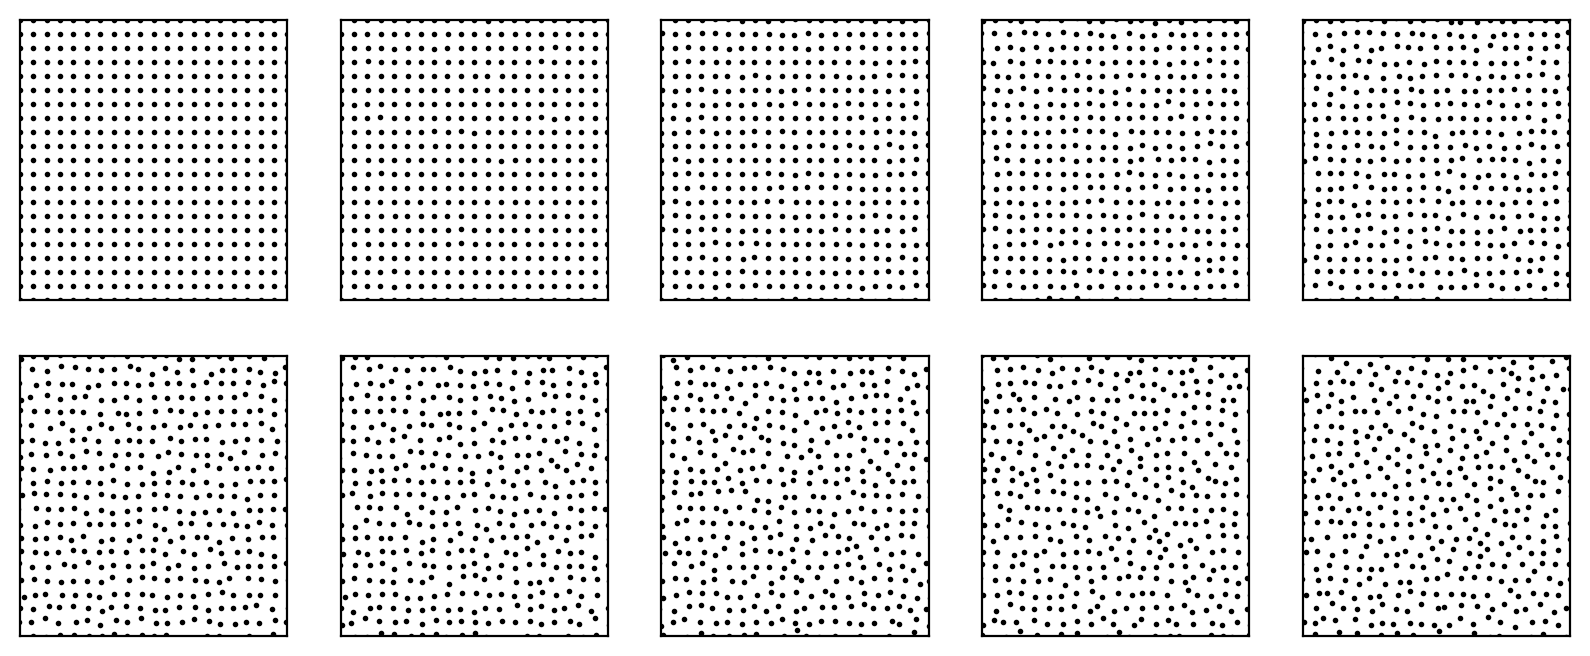

In [ ]:
n_steps = 10


aberage_ehpacing = 1 / (L * np.sqrt(np.pi))
beta = 7  # large beta forbids the system from choosing unlikely points
resolution = 20  # how finely sampled is the area to move to

p_new = p_regular.copy()

fig, ax = plt.subplots(n_steps // 5, 5, figsize=(10, 2 * n_steps // 5), dpi=200)
ax = ax.flatten()
for a, s in zip(tqdm(ax), np.linspace(0.0, 4 * aberage_ehpacing)):

    p_new = move_all_points(p_new, s, s * 2, beta, resolution=30)

    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    s = 1
    a.scatter(*p_new.T, s=s, c="k")
    a.scatter(*(p_new + (0, 1)).T, s=s, c="k")
    a.scatter(*(p_new + (1, 0)).T, s=s, c="k")
    a.scatter(*(p_new + (0, -1)).T, s=s, c="k")
    a.scatter(*(p_new + (-1, 0)).T, s=s, c="k")


plt.show()